In [1]:
# Import core libraries and NUGGET modules
import torch
import numpy as np
import nugget  # Main NUGGET package for neutrino detector optimization
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import importlib
import pickle
import pandas as pd
import plotly.express as px
import time
import os
from nugget.losses.effective_area import get_bounding_cylinder
from IPython.display import clear_output
from pathlib import Path
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
geometry = nugget.geometries.SpaceString.SpaceString(
            hex_type='hexagonal',
            domain_size=1600,  # Size of detector domain
            # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
            dim=3,  # 3D geometry
            n_strings=61,  # Initial number of detector strings
            points_per_string=20,  # Number of PMTs/sensors per string
            # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
            # custom_string_spacing=0.09  # Custom spacing between strings
            starting_spacing=200,
            starting_z_spacing=50
        )
geom_dict = geometry.initialize_points()

Text(0, 0.5, 'Y (m)')

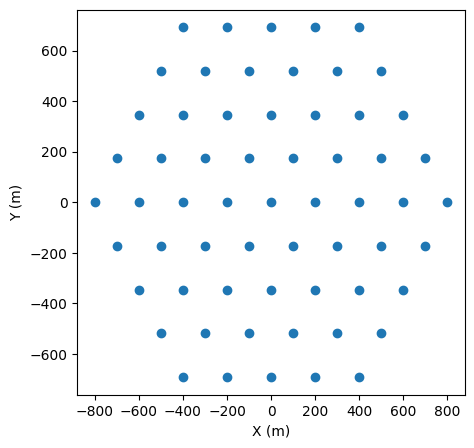

In [16]:
plt.figure(figsize=(5,5))
plt.scatter(geom_dict['string_xy'][:,0].cpu(), geom_dict['string_xy'][:,1].cpu())
plt.xlabel('X (m)')
plt.ylabel('Y (m)')

In [ ]:
string_spacing = 30  # Spacing between strings in the hexagonal grid
z_spacing = 110  # Spacing between points along each string
points_history = []
for hybrid_mix in np.linspace(0, 1, 20):    
    # update the shown plot with new geometry
# hybrid_mix = 1
    geometry = nugget.geometries.SpaceString.SpaceString(
                hex_type='hybrid',
                domain_size=1100,  # Size of detector domain
                # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
                dim=3,  # 3D geometry
                n_strings=200,  # Initial number of detector strings
                points_per_string=2,  # Number of PMTs/sensors per string
                # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
                # custom_string_spacing=0.09  # Custom spacing between strings
                starting_spacing=string_spacing,
                # starting_z_spacing=z_spacing,
                hybrid_mix_init=hybrid_mix,
                hybrid_iter_step=0.01
            )
    geom_dict = geometry.initialize_points()
    points_3d = geom_dict['points_3d']
    points_history.append(points_3d.cpu().numpy())
    # draw curve showing the trajection of each point from points history
    clear_output(wait=True)
    plt.figure(figsize=(6, 6))
    plt.scatter(geom_dict['points_3d'][:,0].cpu(), geom_dict['points_3d'][:,1].cpu())
    for i in range(points_3d.shape[0]):
        history = np.array([points_history[j][i] for j in range(len(points_history))])
        plt.plot(history[:,0], history[:,1], color='gray', alpha=0.3)
    plt.title(f"Hybrid Mix: {hybrid_mix:.2f}")
    plt.xlim(-250, 250)
    plt.ylim(-250, 250)
    plt.show()
    time.sleep(0.1)

In [2]:
device = None
importlib.reload(nugget.samplers.cyl_sampler)
importlib.reload(nugget.surrogates.LightSabre)
importlib.reload(nugget.surrogates.pandel)
# Create a skewed Gaussian surrogate for light yield prediction
# Skewedgauss = nugget.surrogates.SkewedGaussian.SkewedGaussian(sigma_factor=6) 
# light_yield_surrogate = Skewedgauss.light_yield_surrogate

lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(
                                        device=device, 
                                        use_poisson=True, 
                                        domain_size=2000,
                                        particle_mode='track',
                                        )
cascade_surrogate = nugget.surrogates.LightSabre.LightSabre(
                                        device=device, 
                                        use_poisson=True, 
                                        domain_size=2000,
                                        particle_mode='cascade',
                                        )
patd_surrogate = nugget.surrogates.LightSabre.LightSabrePATD(
                                        device=device,
                                        use_poisson=True,
                                        num_track_points=1000,
                                        domain_size=2000,
                                        use_max_energy_dist=True,
                                        use_perpendicular_distance_only=True,
                                        particle_mode='track',
                                        )
patd_light_yield_surrogate = patd_surrogate.light_yield_surrogate
track_light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate
cascade_light_yield_surrogate = cascade_surrogate.light_yield_surrogate
batched_track_surrogate = lightsabre_surrogate.light_yield_surrogate_batched
# light_yield_surrogate = nugget.surrogates.Uniform.Uniform()
# Initialize event samplers for signal and background events
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                        device=device, 
                                        event_type='signal', 
                                        domain_size=2000, 
                                        E_min=1e2, 
                                        E_max=1e8, 
                                        find_exact_intersection=False,
                                        random_position_along_ray=True,  
                                        energy_dist='log_uniform',
                                        cylinder_radius=600,
                                        cylinder_height=1000,
                                        uniform_zenith_sampling=True,
                                        # cos_range=torch.tensor((np.cos(np.pi/2),np.cos(np.pi/2)))
                                        )
# signal_sampler = nugget.samplers.toy_sampler.ToySampler(x_bias=0, event_type='signal', domain_size=2500, E_min=1e6, E_max=1e8)
# background_sampler = nugget.samplers.toy_sampler.ToySampler(x_bias=0, event_type='background', domain_size=2500, E_min=1e6, E_max=1e8)

/tmp/ipykernel_2095120/34379928.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  track_ly += track_light_yield_surrogate(opt_point=points, event_params=event_params).numpy()


Energy: 1.00e+03 GeV, :.2f
tensor(3772.5269)


/tmp/ipykernel_2095120/34379928.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cascade_ly += cascade_light_yield_surrogate(opt_point=points, event_params=event_params).numpy()


Energy: 1.00e+03 GeV, :.2f
tensor(523.3719)


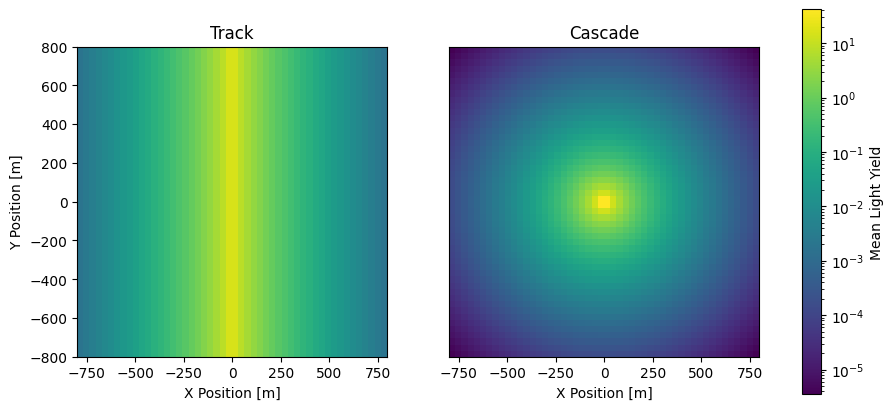

In [38]:
track_signal_events = signal_sampler.sample_events(1)  # Fresh signal events for optimization
cascade_signal_events = signal_sampler.sample_events(1)  # Fresh cascade events for optimization
# new_background_events = background_sampler.sample_events(2)  # Fresh background events
domain_size = 1600
half_size = domain_size / 2
steps = 50
x = np.linspace(-half_size, half_size, steps)
y = np.linspace(-half_size, half_size, steps)
z = np.linspace(-half_size, half_size, steps)
X, Y, Z = np.meshgrid(x, y, z)
points = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
points = torch.tensor(points, dtype=torch.float32)
track_ly = torch.zeros((points.shape[0],))
cascade_ly = torch.zeros((points.shape[0],))
for i, event_params in enumerate(track_signal_events):
    event_params['position'] = torch.tensor([0, 0, 0], dtype=torch.float32)
    event_params['direction'] = torch.tensor([0, 1, 0], dtype=torch.float32)
    event_params['energy'] = torch.tensor(1e3, dtype=torch.float32)
    track_ly += track_light_yield_surrogate(opt_point=points, event_params=event_params).numpy()
    print(f'Energy: {event_params["energy"].item():.2e} GeV, :.2f')
    print(torch.sum(track_ly))
for i, event_params in enumerate(cascade_signal_events):
    event_params['position'] = torch.tensor([0, 0, 0], dtype=torch.float32)
    event_params['direction'] = torch.tensor([0, 1, 0], dtype=torch.float32)
    event_params['energy'] = torch.tensor(1e3, dtype=torch.float32)
    cascade_ly += cascade_light_yield_surrogate(opt_point=points, event_params=event_params).numpy()
    print(f'Energy: {event_params["energy"].item():.2e} GeV, :.2f')
    print(torch.sum(cascade_ly))
cascade_ly = cascade_ly / len(cascade_signal_events)
cascade_ly_reshaped = cascade_ly.numpy().reshape((steps, steps, steps))
avg_cascade_ly = np.sum(cascade_ly_reshaped, axis=2)
avg_cascade_ly[avg_cascade_ly == 0] = 1e-1

track_ly = track_ly / len(track_signal_events)
track_ly_reshaped = track_ly.numpy().reshape((steps, steps, steps))
# then take the average across z axis
avg_track_ly = np.sum(track_ly_reshaped, axis=2)
avg_track_ly[avg_track_ly == 0] = 1e-1
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
shared_vmin = min(
    np.min(avg_track_ly[avg_track_ly > 0]),
    np.min(avg_cascade_ly[avg_cascade_ly > 0]),
)
shared_vmax = max(np.max(avg_track_ly), np.max(avg_cascade_ly))
shared_norm = LogNorm(vmin=shared_vmin, vmax=shared_vmax)

im1 = axes[0].imshow(
    avg_track_ly,
    extent=(-half_size, half_size, -half_size, half_size),
    cmap='viridis',
    norm=shared_norm,
    
)
axes[0].set_xlabel('X Position [m]')
axes[0].set_ylabel('Y Position [m]')
axes[0].set_title('Track')

im2 = axes[1].imshow(
    avg_cascade_ly,
    extent=(-half_size, half_size, -half_size, half_size),
    cmap='viridis',
    norm=shared_norm,
)
axes[1].set_xlabel('X Position [m]')
#remove y tick labels and y label from
axes[1].set_yticks([])
# axes[1].set_ylabel('Y Position [m]')
axes[1].set_title('Cascade')

fig.colorbar(im1, ax=axes.ravel().tolist(), label='Mean Light Yield')

fig.savefig('lightsabre_examples.pdf', dpi=300)


In [3]:
importlib.reload(nugget.surrogates.LLRnet)
llr_net = nugget.surrogates.LLRnet.LLRnet(
    device=device,
    domain_size=2000,  # Size of the detector domain
    dim=3,  # 3D spatial coordinates
    hidden_dims=[64, 64, 64, 64],  # Neural network architecture
    use_fourier_features=False,  # Use Fourier features for better spatial encoding
    num_parallel_branches=1,  # Multiple branches for ensemble learning
    frequency_scales=[0.1, 0.4],  # Different frequency scales for fourier features
    num_frequencies_per_branch=[64,64],  # Number of Fourier features per branch
    learnable_frequencies=False,  # Fixed frequency features
    dropout_rate=0,  # Regularization
    learning_rate=1e-3,  # Optimizer learning rate
    shared_mlp=False,  # Independent MLPs for each branch
    use_residual_connections=True,  # Skip connections for better training
    signal_noise_scale=0,  # Noise level for signal events
    background_noise_scale=0.2,  # Noise level for background events
    add_relative_pos=False,  # Whether to include relative position features
    log_scale_ly=True,  # Whether to log-scale the light yield inputs
    norm_pos=True,  # Whether to normalize position inputs
    log_scale_energy=True,  # Whether to log-scale the energy inputs
    
    reduce_lr_on_plateau=True,  # Reduce learning rate on plateau
    lr_scheduler_patience=35,  # Patience for LR scheduler
    use_patd=False,  # Whether to use PATD features
    use_rich_features=True,  # Whether to use rich features from the surrogate model
    add_distance_from_beam=False,  # Whether to include distance from beam as a feature
)

llr_net.load_model('best_hit_llr_model_v7.pt')
# llr_net.load_model('best_charge_llr_model_v5.pt')

Building parallel network architecture:
  Input dim: 13
  Number of parallel branches: 1
  Shared MLP: False
  Branch 0 MLP with residual connections: 13 -> [64, 64, 64, 64, 64, 64] -> 64
  Final MLP: 64 -> 32 -> 1
  Total trainable parameters: 27,969


In [52]:
importlib.reload(nugget.losses.fisher_info)
importlib.reload(nugget.losses.fisher_info_helpers)
importlib.reload(nugget.losses.effective_area)
importlib.reload(nugget.losses.trigger)
importlib.reload(nugget.losses.analysis_loss)
angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=device,
    resolution_type='angular',
    fisher_info_params=['energy', 'direction']
)
analysis_loss = nugget.losses.analysis_loss.AnalysisLoss(
    device=device,
    fisher_info_params=['energy', 'direction'],
)

# Energy Resolution: Optimizes detector's ability to reconstruct particle energy
# energy_resolution_loss = nugget.losses.fisher_info.ResolutionLoss(
#     # device=geometry.device,
#     device=device,
#     resolution_type='energy',
#     fisher_info_params=['position','energy', 'direction'])

trigger_loss = nugget.losses.trigger.TriggerLoss(
    device=device,
    light_yield_threshold=6.0,
    distance_bar_length=550.0,
    distance_bar_step=25.0,
    min_points_threshold=30.0,
    t1_temperature=5.0,
    t3_temperature=5.0,
    t_temperature=5.0, 
    use_hard_cuts=False,
)
# effective_area_loss = nugget.losses.effective_area.EffectiveAreaLoss(
#     device=device,
#     domain_size=1200,
#     trigger=trigger_loss
#     )

In [32]:
llr_net.domain_size 

2000

In [19]:
test_signal_events = signal_sampler.sample_events(3)  # Fresh signal events for optimization

In [58]:

# test_signal_events[0]['position'] = torch.tensor([0.0,0.0,0.0])

geometry = nugget.geometries.EvanescentString.EvanescentString(
            device=device,
            hex_type='hexagonal',
            domain_size=2000,  # Size of detector domain
            # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),  # Use GPU if available
            dim=3,  # 3D geometry
            n_strings=1027,  # Initial number of detector strings
            points_per_string=20,  # Number of PMTs/sensors per string
            # starting_weight=-0.5,  # Initial weight for each string (controls visibility)
            # custom_string_spacing=0.09  # Custom spacing between strings
            # starting_spacing=100,
            # starting_z_spacing=64336740
            custom_z_spacing=50,
            # random_weights=True,
            starting_weight = 100
        )
# geometry = nugget.geometries.SpaceString.SpaceString(
#             device=device,
#             hex_type='hexagonal',
#             domain_size=2500,
#             dim=3,
#             n_strings=70,
#             points_per_string=20,
#             starting_spacing=80,
#             starting_z_spacing=50
#         )
geom_dict = geometry.initialize_points(
    # initial_geometry=pickle.load(open('/u/kristiantcho/ptmp/nugget/nugget/examples/best_geom_res_test_alm_ang_res_no_rov_100_2.pkl', 'rb'))
)
loss_params = {
'num_events': 100,
'signal_surrogate_func': track_light_yield_surrogate,
'skip_zero_response': True,
# 'fisher_info_llr_net': llr_net,
'use_relative_energy': True,
'signal_sampler': signal_sampler,
# 'num_events':len(test_signal_events),
'signal_event_params': nugget.utils.data_tools.load_signal_events_parquet('res_test/signal_events_9000_r600_50_u_sp_1_vertical.pt'),
'precomputed_fisher_info_per_string_per_event': torch.load('res_test/fisher_info_per_string_per_event_9000_800main_full_hex_r600_50_u_sp_1_vertical.pt'),
'trigger_loss': trigger_loss,
# 'signal_event_params': [pickle.load(open('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test_signal_events_100_2.pkl', 'rb'))[1]],
'fisher_info_llr_iterations': 300,
'llr_event_labels': ['position','energy', 'direction'],
'fisher_info_event_batch_size': 1,
'fisher_info_grad_chunk_size': 14,
'fisher_info_jacrev_chunk_size': 50000,
'fisher_info_point_chunk_size': 20000,
'fisher_info_llr_autodiff_mode': 'jvp',
'fisher_info_detach_tensors': True,
'fisher_info_use_patd': True,
# 'eval_patd_log_probs':patd_surrogate.eval_patd_log_probs,
'use_rich_features': True,
'use_patd_quadrature': True,
't_offset_ns': 0.0,
't_max_ns': 5000.0,
'use_charge_quadrature': False,
'charge_center_on_llr_peak': True,
'charge_peak_scan_points':64,
'adaptive_grid_retry':True,
'adaptive_t_max_floor_ns':10,
'uninformative_fisher_value':1e-6,
'empty_cache_after_event': True,
'live_time': 10*np.pi*1e7,
'perfect_efficiency': True,

'bounding_cylinder_temperature': 0.1,
'use_batched_trigger': True,
'use_batched_binned_trigger': True,
'use_irregular_cylinder': False,
'num_events_per_bin': 100,
'num_energy_bins': 30,
'num_zenith_bins': 30,
'per_event_effective_area_loss': False,
'perfect_efficiency': False,
'cos_zenith_range': (-1, 0),
'binned_trigger_batch_size': 500,
'batched_surrogate_func': batched_track_surrogate,
'detach_trigger': False,


# 'precomputed_fisher_info_per_string_per_event': torch.load('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test_fisher_info_per_string_per_event_100_base_geom_2.pt')
}
loss_dict = analysis_loss(geom_dict, **loss_params)
# new_loss_dict = effective_area_loss(geom_dict, **loss_params)
# loss_dict = trigger_loss(geom_dict, **loss_params)
# loss_dict = angular_resolution_loss(geom_dict, **loss_params)
# loss_dict = effective_area_loss(geom_dict, **loss_params)
# fisher_info_per_string_per_event_20 = angular_resolution_loss.compute_fisher_info_per_string_per_event(
#             string_xy=geom_dict['string_xy'],
#             points_3d=geom_dict['points_3d'],
#             signal_event_params=signal_event,
#             signal_surrogate_func=light_yield_surrogate,
#             llr_net=llr_net,
#             llr_iterations=20,
#             skip_zero_response=True,
#             verbose=True
#             )
# print(loss_dict['resolution_per_event']*180/3.14159)  # convert to degrees
# print(loss_dict['angular_resolution_loss']*180/3.14159)  # convert to degrees
# print(loss_dict['detector_efficiency'])

/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info_helpers.py:1839: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)


counts: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
counts: tensor([[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 1.0000, 0.0000, 0.0000],
        [0.0000, 1.0000, 0.0000,  ..., 0.0000, 0.0000, 0.9894]])


In [59]:
loss_dict

{'fisher_analysis_loss': tensor(1.0596e+10, dtype=torch.float64)}

In [33]:
torch.ones(100)*torch.ones(100)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

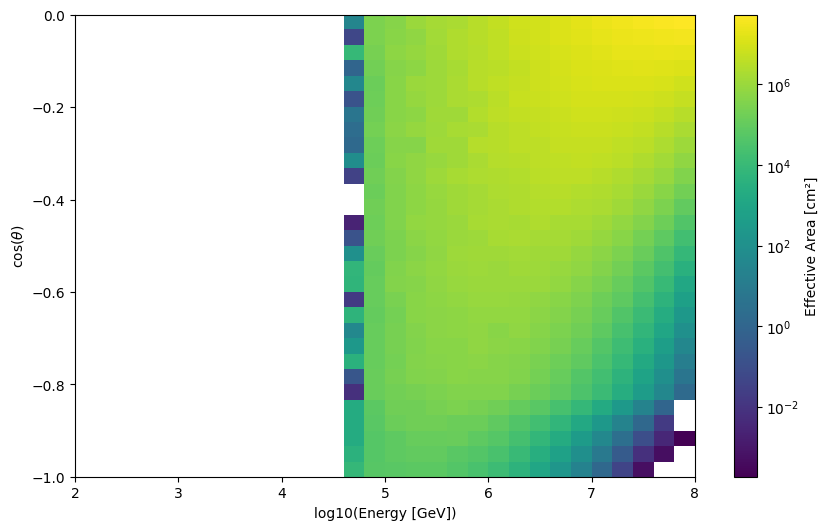

In [18]:
energy_range = (1e2, 1e8)
zenith_range = (-1,0)
num_energy_bins = 30
num_zenith_bins = 30
energy_bins = torch.linspace(np.log10(energy_range[0]), np.log10(energy_range[1]), num_energy_bins+1)
zenith_bins = torch.linspace(zenith_range[0], zenith_range[1], num_zenith_bins+1)
energy_centers = 10**((energy_bins[:-1] + energy_bins[1:]) / 2)
zenith_centers = (zenith_bins[:-1] + zenith_bins[1:]) / 2
effective_areas = new_loss_dict['effective_area_matrix'].cpu().numpy()*1e4
effective_areas[effective_areas < 1e-4] = None
# effective_areas = new_loss_dict['detector_efficiencies'].cpu().numpy()
#plot heatmap with mplotlib
plt.figure(figsize=(10, 6))
# rotate the effective area matrix so that the x axis corresponds to energy and y axis corresponds to zenith
plt.imshow(effective_areas, 
           extent=[np.log10(energy_range[0]), np.log10(energy_range[1]), zenith_range[0], zenith_range[1]], 
           aspect='auto', 
           origin='lower',
           cmap='viridis',
           norm=LogNorm()
)
#scale colorbar to log scale
plt.colorbar(label='Effective Area [cm²]')
# plt.colorbar(label='Detector Efficiency')
# plt.ylabel(r'$\sin(\delta)$')
plt.ylabel(r'$\cos(\theta)$')
plt.xlabel('log10(Energy [GeV])')
plt.show()


In [10]:
light_yield = light_yield_surrogate(opt_point=points_3d, event_params=true_event_params).numpy()
df = pd.DataFrame(points_3d.cpu().numpy(), columns=['x', 'y', 'z'])
df['light_yield'] = light_yield
# df['light_yield'] = np.log10(light_yield)
df['light_yield'][df['light_yield'] < 0] = 0
df['size'] = 10*light_yield/light_yield 
# plot the points and then overlay these with the same points but scaled with light yield, the initial points should be small and grey, the overlayed points should be colored with a colorscale according to light yield
fig = px.scatter_3d(df, x='x', y='y', z='z', opacity=0.7, size='size', size_max=7)
fig.add_trace(px.scatter_3d(df, x='x', y='y', z='z', color='light_yield', color_continuous_scale='viridis', size='light_yield', size_max=30).data[0])
fig.show()



/tmp/ipykernel_2461693/32412615.py:5: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


